In [1]:
!git clone https://github.com/PietroSchgor/PietroSchgor-Thesis-Gen.-AI-Models-for-MRI-Synthesis.git

Cloning into 'PTNet3D'...
remote: Enumerating objects: 240, done.
remote: Counting objects: 100% (76/76), done.
remote: Compressing objects: 100% (41/41), done.
remote: Total 240 (delta 48), reused 49 (delta 35), pack-reused 164 (from 1)
Receiving objects: 100% (240/240), 1.13 MiB | 21.51 MiB/s, done.
Resolving deltas: 100% (100/100), done.


In [2]:
!git pull

fatal: not a git repository (or any parent up to mount point /kaggle)
Stopping at filesystem boundary (GIT_DISCOVERY_ACROSS_FILESYSTEM not set).


In [3]:
%cd /kaggle/working/PietroSchgor-Thesis-Gen.-AI-Models-for-MRI-Synthesis/PTNet3D
!git pull
!pip install -r requirements.txt

/kaggle/working/PTNet3D
Already up to date.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 96.0 MB/s eta 0:00:00
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 

In [4]:


!python train.py \
    --dir_A "/kaggle/input/datasets/pietrofilipposchgor/t1-flair/T1 - FLAIR/FLAIR" \
    --dir_B "/kaggle/input/datasets/pietrofilipposchgor/t2-train" \
    --code_list "/kaggle/input/datasets/giuliasteiner/t2-flair-codici-comuni/lista_codici_TRAIN.txt" \
    --checkpoints_dir check_dir \
    --batchSize 4 \
    --nThreads 4 \
    --patch_size "(64, 64, 64)" \
    --name "FLAIR_T2" \
    --niter 0 \
    --niter_decay 150 \
    --save_epoch_freq 50 \
    --display_freq 1000 \
    --print_freq 400 \
    --resume_D "/kaggle/input/models/elenaschgor/ptnet-flair-t2/pytorch/default/7/D_1090.pth" \
    --resume_G "/kaggle/input/models/elenaschgor/ptnet-flair-t2/pytorch/default/7/PTNet_1090.pth"

    

------------ Options -------------
batchSize: 4
beta1: 0.9
checkpoints_dir: check_dir
code_list: /kaggle/input/datasets/giuliasteiner/t2-flair-codici-comuni/lista_codici_TRAIN.txt
dataroot: tmp
debug: False
dimension: 3D
dir_A: /kaggle/input/datasets/pietrofilipposchgor/t1-flair/T1 - FLAIR/FLAIR
dir_B: /kaggle/input/datasets/pietrofilipposchgor/t2-train
display_freq: 1000
display_winsize: 512
extension: .nii
gpu_ids: [0]
input_nc: 1
isTrain: True
lr: 0.0002
nThreads: 4
name: FLAIR_T2
niter: 0
niter_decay: 150
no_html: False
norm_perc: 99.95
patch_size: (64, 64, 64)
phase: train
print_freq: 400
remove_bg: True
resume_D: /kaggle/input/models/elenaschgor/ptnet-flair-t2/pytorch/default/7/D_1090.pth
resume_G: /kaggle/input/models/elenaschgor/ptnet-flair-t2/pytorch/default/7/PTNet_1090.pth
save_epoch_freq: 50
save_latest_freq: 1000
-------------- End ----------------
Paired/aligned dataloader
dataset [Paired/Aligned Dataset] was created
DEBUG INFO MATCHER:
- Codici richiesti (dal txt): 399
-

✅ Grafico salvato con successo in: /kaggle/working/grafici_loss/grafico_epoch.png


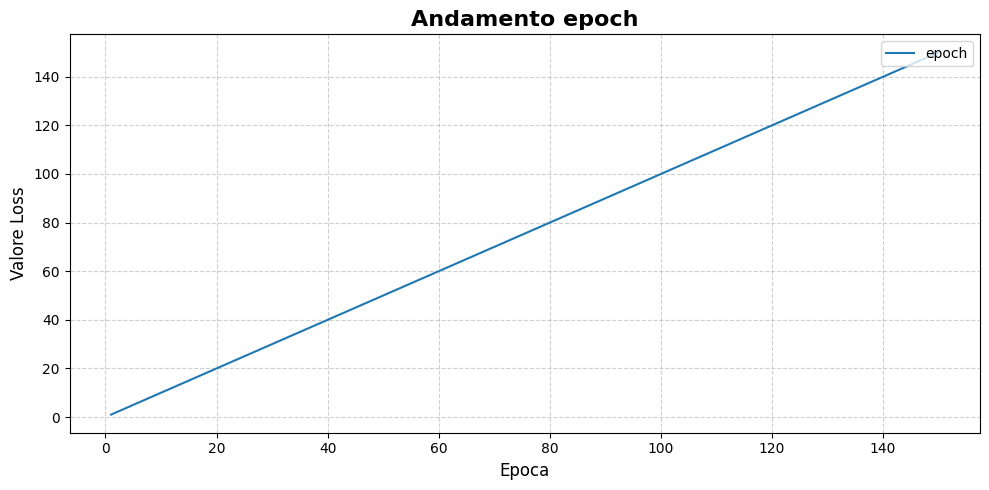

✅ Grafico salvato con successo in: /kaggle/working/grafici_loss/grafico_iters.png


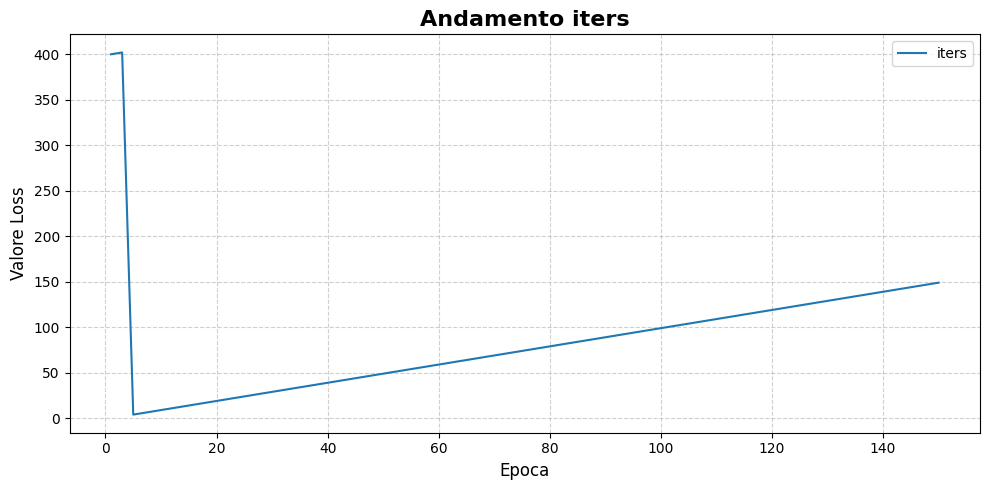

✅ Grafico salvato con successo in: /kaggle/working/grafici_loss/grafico_MSE.png


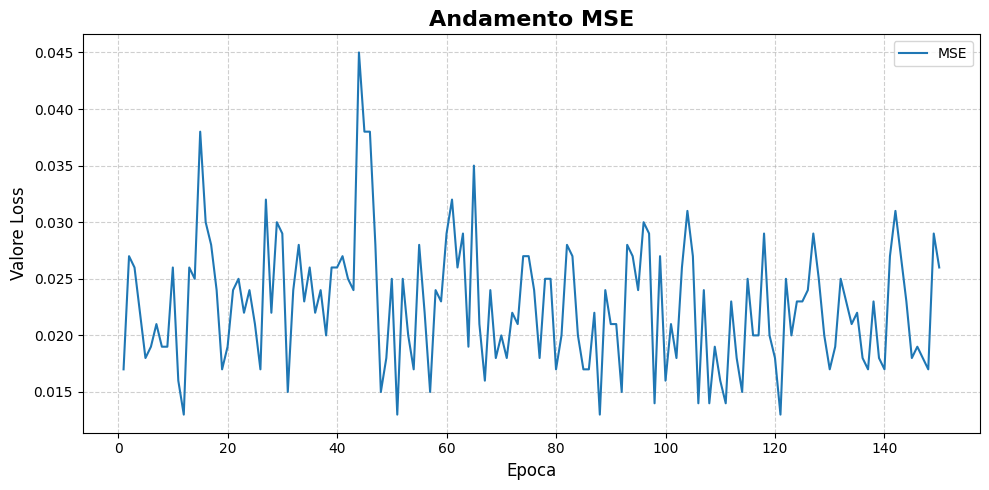

✅ Grafico salvato con successo in: /kaggle/working/grafici_loss/grafico_G_GAN.png


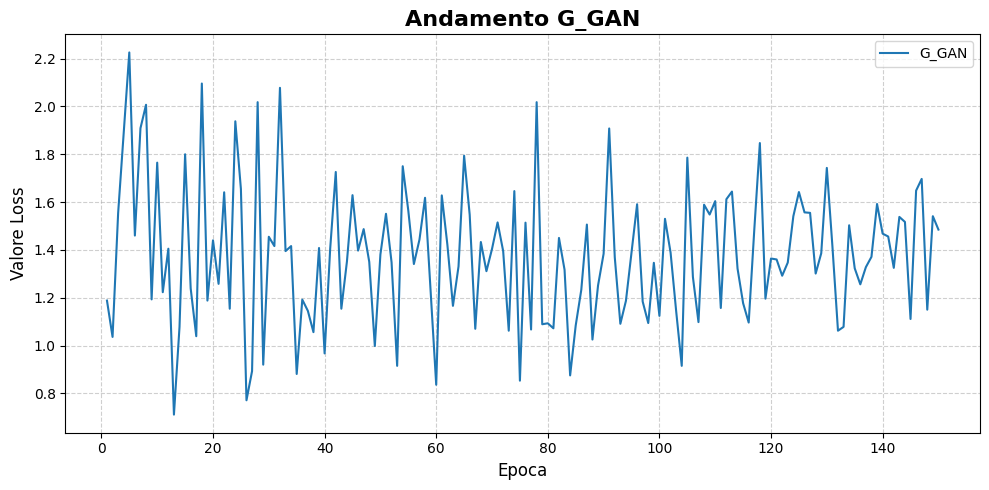

✅ Grafico salvato con successo in: /kaggle/working/grafici_loss/grafico_G_GAN_Feat_ext.png


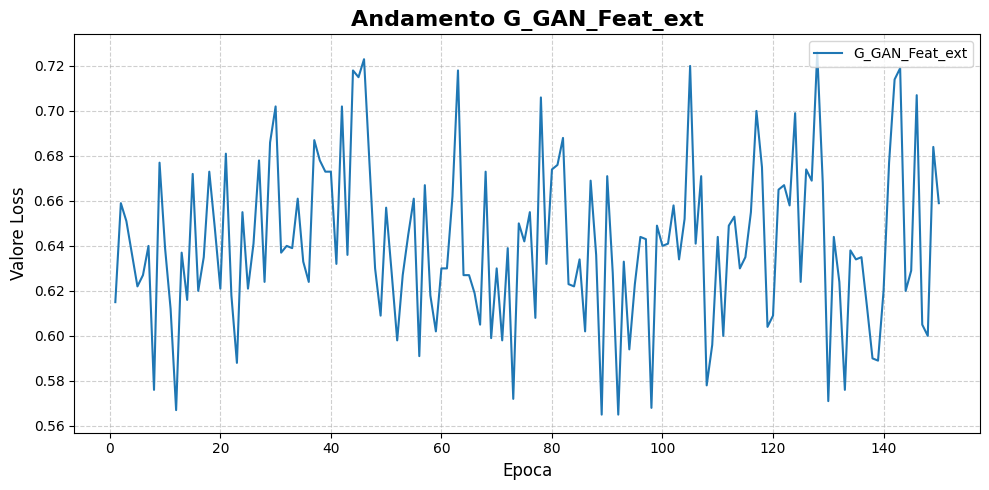

✅ Grafico salvato con successo in: /kaggle/working/grafici_loss/grafico_G_GAN_Feat.png


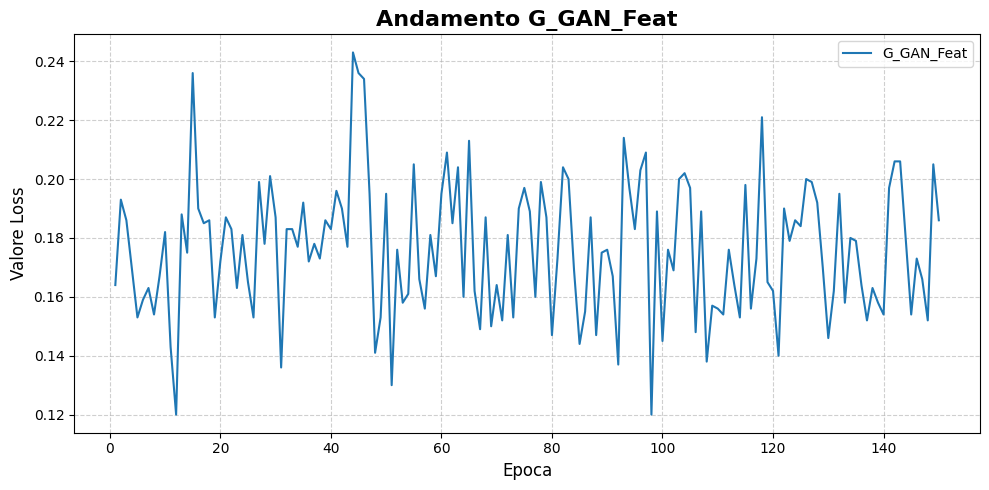

✅ Grafico salvato con successo in: /kaggle/working/grafici_loss/grafico_D_fake.png


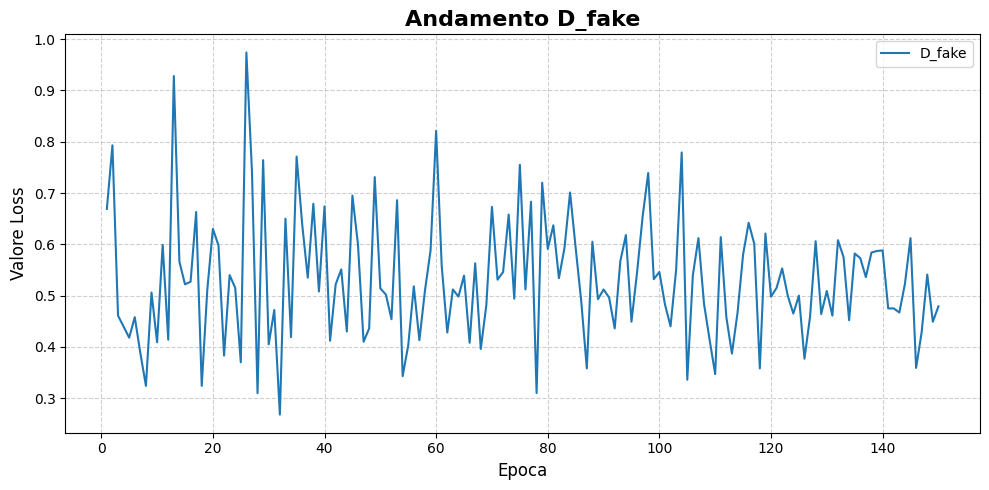

✅ Grafico salvato con successo in: /kaggle/working/grafici_loss/grafico_D_real.png


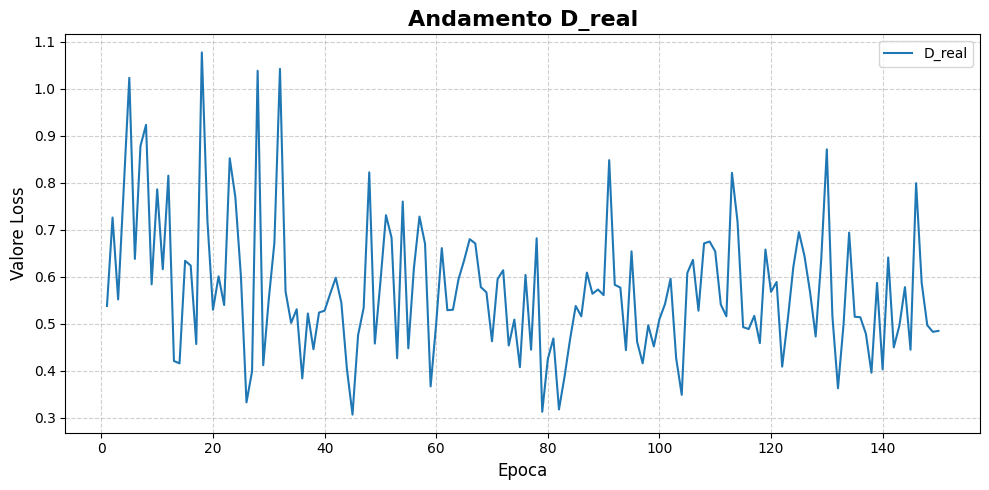

In [5]:
import matplotlib.pyplot as plt
import re
import os
from collections import defaultdict

# 1. IMPOSTAZIONI DEI PERCORSI
percorso_log = '/kaggle/working/PietroSchgor-Thesis-Gen.-AI-Models-for-MRI-Synthesis/PTNet3D/check_dir/FLAIR_T2/loss_log.txt' 
cartella_salvataggio = '/kaggle/working/grafici_loss/' 

# Crea la cartella per salvare le immagini se non esiste già
os.makedirs(cartella_salvataggio, exist_ok=True)

# Dizionari per accumulare i dati
storico_loss = defaultdict(list)
storico_epoche = []

try:
    # 2. LETTURA E PARSING DEL LOG
    with open(percorso_log, 'r') as f:
        for riga in f:
            if '================' in riga or not riga.strip():
                continue
            
            # Cerca il numero dell'epoca (es. "epoch: 4") e salvalo
            match_epoca = re.search(r'epoch:\s*(\d+)', riga)
            if match_epoca:
                epoca_corrente = int(match_epoca.group(1))
                storico_epoche.append(epoca_corrente)
                
            # Trova tutte le metriche e salvale nel dizionario
            match_loss = re.findall(r'([A-Za-z_]+):\s*([\d\.]+)', riga)
            for nome_loss, valore in match_loss:
                if nome_loss != 'time':
                    storico_loss[nome_loss].append(float(valore))
                    
    # 3. CREAZIONE E SALVATAGGIO DEI GRAFICI SEPARATI
    for nome_loss, valori in storico_loss.items():

        plt.figure(figsize=(10, 5))

        plt.plot(storico_epoche, valori, label=nome_loss, color='#1f77b4', linewidth=1.5)
        
        # Testi e griglia
        plt.title(f'Andamento {nome_loss}', fontsize=16, fontweight='bold')
        plt.xlabel('Epoca', fontsize=12)
        plt.ylabel('Valore Loss', fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend(loc='upper right', fontsize=10)
        plt.tight_layout()
        
        # Salvataggio dell'immagine
        nome_file = f'grafico_{nome_loss}.png'
        percorso_file = os.path.join(cartella_salvataggio, nome_file)
        plt.savefig(percorso_file, dpi=300, bbox_inches='tight')
        
        print(f"✅ Grafico salvato con successo in: {percorso_file}")

        plt.show()

except FileNotFoundError:
    print(f"❌ Errore: Il file {percorso_log} non esiste ancora! Controlla il percorso.")